In [2]:
## IMPORTS 
import os
import sys 
LOCSCALE_2_SCRIPTS_PATH = "/home/abharadwaj1/papers/publications/2025_LocScale-2.0"
PLOT_DATA_STORE_PATH = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data"
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from scipy import stats
import pandas as pd
import seaborn as sns
from scripts.utils.plot_utils import plot_correlations
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist

random.seed(42)
np.random.seed(42)

## Supplementary 1 b

In [3]:
# num_atoms_json_file = os.path.join(PLOT_DATA_STORE_PATH, "num_atoms_pdb_pseudomodel.json")

# num_atoms_df = pd.read_json(num_atoms_json_file)
# num_atoms_df = num_atoms_df.reset_index()

# num_atoms_df.columns = ["EMDB ID", "num_pseudoatoms_non_hydrogenated", "num_pseudoatoms_hydrogenated", "num_atoms_non_hydrogenated", "num_atoms_hydrogenated"]
csv_save_path = os.path.join(PLOT_DATA_STORE_PATH, "s1_b_num_atoms_pdb_pseudomodel.csv")
# num_atoms_df.to_csv(csv_save_path, index=False)

num_atoms_df = pd.read_csv(csv_save_path)


In [4]:
num_atoms_df.head()

,emdb_pdb,num_pseudoatoms_non_hydrogenated,num_pseudoatoms_hydrogenated,num_atoms_non_hydrogenated,num_atoms_hydrogenated
0,0026_6gl7,12310,31910,13506,26678
1,7573_6crv,17789,34204,21036,41625
2,0665_6oa9,34782,50324,29006,58068
3,0038_6gml,38590,60685,44827,88044
4,0071_6gve,26001,56554,33412,66364


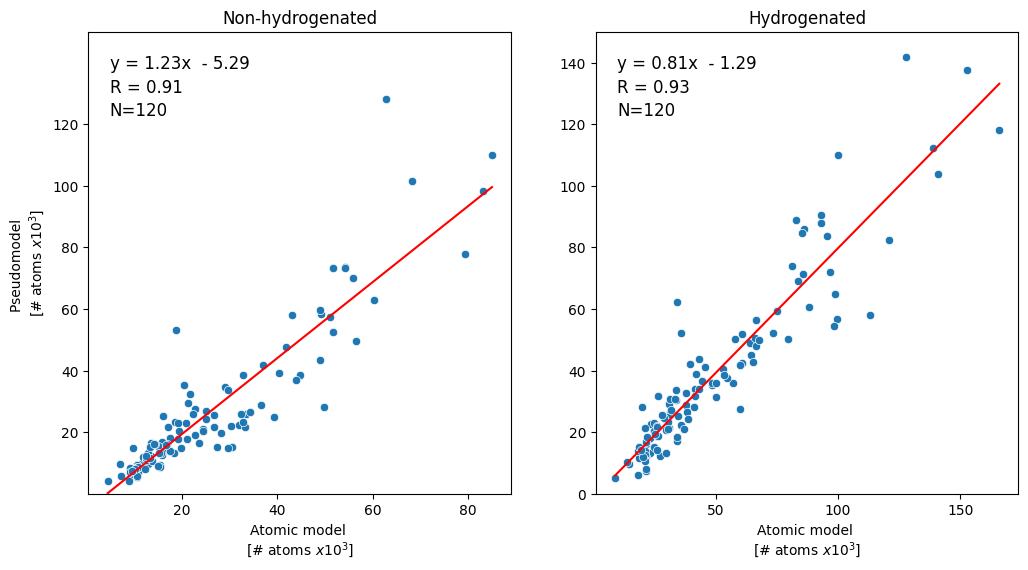

In [7]:
x_array_non_hydrogenated = np.array(list(num_atoms_df["num_atoms_non_hydrogenated"].values)) / 1000
#x_array_num_atoms_pdb = np.array(list(num_atoms_pdb_hydr.values()))
y_array_non_hydrogenated = np.array(list(num_atoms_df["num_pseudoatoms_non_hydrogenated"].values)) / 1000

slope, intercept, r_value, p_value, std_err = stats.linregress(x_array_non_hydrogenated, y_array_non_hydrogenated)
y_fit_non_hydrogenated = slope * x_array_non_hydrogenated + intercept        
sign = "+" if intercept > 0 else "-"
equation_text = f"y = {slope:.2f}x  {sign} {abs(intercept):.2f}"
r_text = f"R = {r_value:.2f}"
num_data_points = len(x_array_non_hydrogenated)
data_text = f"N={num_data_points}"

x_array_hydrogenated = np.array(list(num_atoms_df["num_atoms_hydrogenated"].values)) / 1000
y_array_hydrogenated = np.array(list(num_atoms_df["num_pseudoatoms_hydrogenated"].values)) / 1000
slope, intercept, r_value, p_value, std_err = stats.linregress(x_array_hydrogenated, y_array_hydrogenated)
y_fit_hydrogenated = slope * x_array_hydrogenated + intercept
sign = "+" if intercept > 0 else "-"
equation_text_hydr = f"y = {slope:.2f}x  {sign} {abs(intercept):.2f}"
r_text_hydr = f"R = {r_value:.2f}"
num_data_points = len(x_array_hydrogenated)
data_text = f"N={num_data_points}"

fig, ax = plt.subplots(1, 2, figsize=(12,6))
sns.scatterplot(x=x_array_non_hydrogenated, y=y_array_non_hydrogenated, ax=ax[0])
sns.lineplot(x=x_array_non_hydrogenated, y=y_fit_non_hydrogenated, color='red', ax=ax[0])
ax[0].text(0.05, 0.95, equation_text, transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].text(0.05, 0.9, r_text, transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].text(0.05, 0.85, data_text, transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].set_xlabel("Atomic model \n[# atoms $x 10^3$]")
ax[0].set_ylabel("Pseudomodel \n[# atoms $x 10^3$]")

y_ticks = [20, 40, 60, 80, 100, 120]
x_ticks = [20, 40, 60, 80]
ax[0].set_yticks(y_ticks);
ax[0].set_xticks(x_ticks);
y_lims = [0, 150]
ax[0].set_ylim(y_lims)
sns.scatterplot(x=x_array_hydrogenated, y=y_array_hydrogenated, ax=ax[1])
sns.lineplot(x=x_array_hydrogenated, y=y_fit_hydrogenated, color='red', ax=ax[1])
ax[1].text(0.05, 0.95, equation_text_hydr, transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[1].text(0.05, 0.9, r_text_hydr, transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[1].text(0.05, 0.85, data_text, transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[1].set_xlabel("Atomic model \n[# atoms $x 10^3$]")
ax[1].set_ylabel("")
#ax[1].set_yticks([]);
ax[1].set_ylim(y_lims)
x_ticks_hydr = [50, 100, 150]
#ax[1].set_yticks(y_ticks);
ax[1].set_xticks(x_ticks_hydr);
ax[0].set_title("Non-hydrogenated")
ax[1].set_title("Hydrogenated")
plt.show()


## Supplementary 1 c

Text(0, 0.5, 'Density')

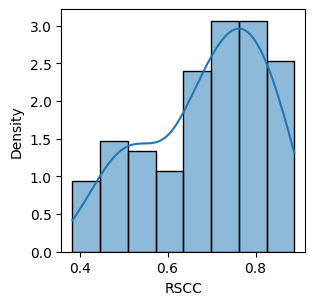

In [8]:
rscc_list = os.path.join(PLOT_DATA_STORE_PATH, "supplement_1_c_rscc_values.csv")
rscc_df = pd.read_csv(rscc_list)

figsize_cm = (8, 8)
figsize_inch = (figsize_cm[0] / 2.54, figsize_cm[1] / 2.54)
plt.figure(figsize=figsize_inch)
sns.histplot(list(rscc_df["rscc"].values), kde=True, stat="density", bins=8)
plt.xlabel("RSCC")
plt.ylabel("Density")

## Supplementary 1 d

In [9]:
# molecular_weight_json_file = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/fdr_analysis_num_atoms/mol_weight_fdr_sequence.json"
# molecular_weight_df = pd.read_json(molecular_weight_json_file).reset_index()
# molecular_weight_df["cluster"] = molecular_weight_df["rscc_mask"] > molecular_weight_df["rscc_cutoff"]
# molecular_weight_df["cluster"] = molecular_weight_df["cluster"].astype(int)
# molecular_weight_df["molecular_weight_sequence"] = molecular_weight_df["molecular_weight_sequence"] / 1000
# molecular_weight_df["molecular_weight_fdr"] = molecular_weight_df["molecular_weight_fdr"] / 1000
# molecular_weight_df.head()

molecular_weight_df_csv_save_path = os.path.join(PLOT_DATA_STORE_PATH, "s1_d_mol_weight_fdr_sequence.csv")
# molecular_weight_df.to_csv(molecular_weight_df_csv_save_path, index=True)

molecular_weight_df = pd.read_csv(molecular_weight_df_csv_save_path)


(0.0, 2400.0)

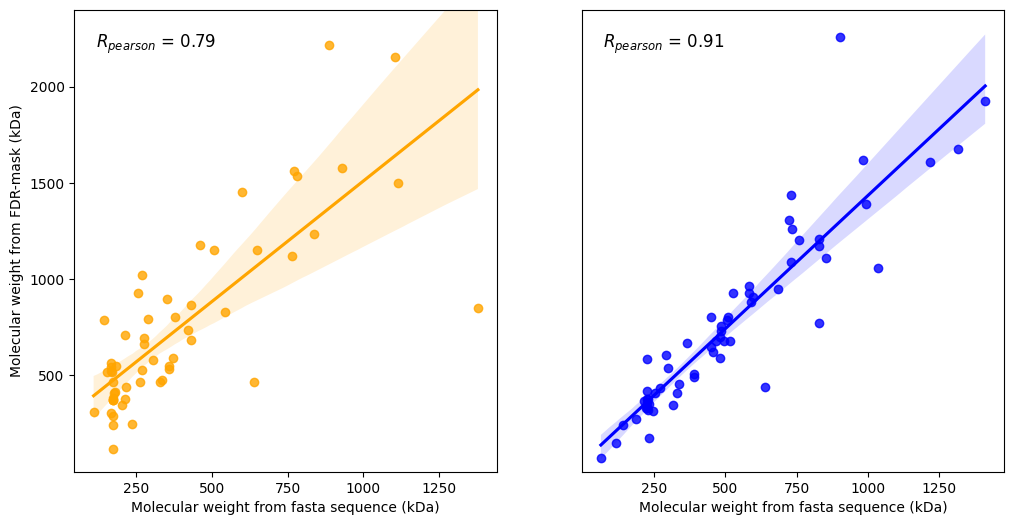

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
sns.regplot(data=molecular_weight_df[molecular_weight_df["cluster"]==0], x="molecular_weight_sequence", y="molecular_weight_fdr", ax=ax[0], color="orange")
sns.regplot(data=molecular_weight_df[molecular_weight_df["cluster"]==1], x="molecular_weight_sequence", y="molecular_weight_fdr", ax=ax[1], color="blue")
pearson_r_cluster_0 = molecular_weight_df[molecular_weight_df["cluster"]==0][["molecular_weight_sequence", "molecular_weight_fdr"]].corr(method='pearson').iloc[0,1]
pearson_r_cluster_1 = molecular_weight_df[molecular_weight_df["cluster"]==1][["molecular_weight_sequence", "molecular_weight_fdr"]].corr(method='pearson').iloc[0,1]
r_text_0 = f"$R_{{pearson}}$ = {pearson_r_cluster_0:.2f}"
r_text_1 = f"$R_{{pearson}}$ = {pearson_r_cluster_1:.2f}"
ax[0].text(0.05, 0.95, r_text_0, transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[1].text(0.05, 0.95, r_text_1, transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[0].set_xlabel("Molecular weight from fasta sequence (kDa)")
ax[0].set_ylabel("Molecular weight from FDR-mask (kDa)")
ax[1].set_xlabel("Molecular weight from fasta sequence (kDa)")
# hide second y axis label and ticks
ax[1].set_ylabel("")
ax[1].set_yticks([]);
x_ticks = [250, 500, 750, 1000, 1250]
y_ticks = [500, 1000, 1500, 2000]
ax[0].set_xticks(x_ticks);
ax[1].set_xticks(x_ticks);
ax[0].set_yticks(y_ticks);
ax[1].set_ylim([0, 2400])
ax[0].set_ylim([0, 2400])